#  Первое домашнее задание
Оценка стоимости авто по объявлениям


## 1.Подготовка датасета

Подключаем библиотеки


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

Описание датасета:
В датасета представлены данные о продаже автомобиля, предположительно в Германии.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
url = "/content/drive/MyDrive/autos.csv"
data_raw = pd.read_csv(url)

In [4]:
data_raw.shape

(371528, 21)

In [5]:
data_raw

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,...,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,...,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,...,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,...,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


In [6]:
data_raw.head(10)

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,5,2016-04-04 17:36:23,BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...,privat,Angebot,650,test,limousine,1995,manuell,...,3er,150000,10,benzin,bmw,ja,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,6,2016-04-01 20:48:51,Peugeot_206_CC_110_Platinum,privat,Angebot,2200,test,cabrio,2004,manuell,...,2_reihe,150000,8,benzin,peugeot,nein,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,...,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,8,2016-04-04 23:42:13,Ford_C___Max_Titanium_1_0_L_EcoBoost,privat,Angebot,14500,control,bus,2014,manuell,...,c_max,30000,8,benzin,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,9,2016-03-17 10:53:50,VW_Golf_4_5_tuerig_zu_verkaufen_mit_Anhaengerk...,privat,Angebot,999,test,kleinwagen,1998,manuell,...,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


In [7]:
data_raw.tail(10)

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
371518,371518,2016-04-02 20:37:03,Bmw_320_D_DPF_Touring_!!!,privat,Angebot,3999,test,kombi,2005,manuell,...,3er,150000,5,diesel,bmw,nein,2016-04-02 00:00:00,0,81825,2016-04-06 20:47:12
371519,371519,2016-03-09 13:37:43,Alfa_Romeo_159_Jtdm_1.9_150_ps_13_600_km_top_voll,privat,Angebot,5250,control,NaN,2016,automatik,...,159,150000,12,NaN,alfa_romeo,nein,2016-03-09 00:00:00,0,51371,2016-03-13 01:44:13
371520,371520,2016-03-19 19:53:49,turbo_defekt,privat,Angebot,3200,control,limousine,2004,manuell,...,leon,150000,5,benzin,seat,ja,2016-03-19 00:00:00,0,96465,2016-03-19 20:44:43
371521,371521,2016-03-27 20:36:20,Opel_Zafira_1.6_Elegance_TÜV_12/16,privat,Angebot,1150,control,bus,2000,manuell,...,zafira,150000,3,benzin,opel,nein,2016-03-27 00:00:00,0,26624,2016-03-29 10:17:23
371522,371522,2016-03-21 09:50:58,Mitsubishi_Cold,privat,Angebot,0,control,NaN,2005,manuell,...,colt,150000,7,benzin,mitsubishi,ja,2016-03-21 00:00:00,0,2694,2016-03-21 10:42:49
371523,371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,...,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,...,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,...,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,...,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21
371527,371527,2016-03-07 19:39:19,BMW_M135i_vollausgestattet_NP_52.720____Euro,privat,Angebot,28990,control,limousine,2013,manuell,...,m_reihe,50000,8,benzin,bmw,nein,2016-03-07 00:00:00,0,73326,2016-03-22 03:17:10


In [8]:
data_raw.sample(10)

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
66294,66294,2016-03-27 20:55:29,Fiat_Coupe_2.0_Turbo_16V,privat,Angebot,7500,control,coupe,1994,manuell,...,andere,100000,8,benzin,fiat,nein,2016-03-27 00:00:00,0,83278,2016-04-05 20:17:38
9651,9651,2016-04-01 18:58:23,Mercedes_Benz_SLK_200_Kompressor_Automatik,privat,Angebot,12400,control,cabrio,2005,automatik,...,slk,100000,5,benzin,mercedes_benz,nein,2016-04-01 00:00:00,0,67459,2016-04-05 14:47:22
298837,298837,2016-04-02 10:41:52,Nissan_Micra_K11,privat,Angebot,170,test,NaN,2016,manuell,...,micra,150000,0,NaN,nissan,NaN,2016-04-02 00:00:00,0,53859,2016-04-04 07:17:44
170512,170512,2016-03-08 20:55:30,Golf_zu_verkaufen,privat,Angebot,600,control,NaN,2016,manuell,...,golf,150000,10,benzin,volkswagen,NaN,2016-03-08 00:00:00,0,14669,2016-04-06 01:17:05
207662,207662,2016-03-05 19:56:11,Volvo_V50_1_6D_DRIVe_Kinetic_mit_Xenon,privat,Angebot,8450,test,kombi,2010,manuell,...,v50,100000,6,diesel,volvo,nein,2016-03-05 00:00:00,0,52076,2016-03-21 05:18:25
231852,231852,2016-03-26 21:49:20,Mercedes_Benz_Vito_115_CDI__Mixto,privat,Angebot,2655,control,bus,2004,manuell,...,vito,150000,7,diesel,mercedes_benz,nein,2016-03-26 00:00:00,0,39576,2016-03-26 21:49:20
16862,16862,2016-03-21 22:38:17,Volkswagen_Crafter_35_TDI_DPF,privat,Angebot,17500,control,kombi,2008,manuell,...,andere,125000,3,diesel,volkswagen,nein,2016-03-21 00:00:00,0,80937,2016-04-07 02:46:27
37047,37047,2016-03-17 23:59:07,Mercedes_Benz_C_200_T_Kompressor_Classic,privat,Angebot,4800,control,kombi,2004,manuell,...,c_klasse,150000,4,benzin,mercedes_benz,nein,2016-03-17 00:00:00,0,49584,2016-04-05 21:18:28
90502,90502,2016-03-07 20:54:15,Mini_Cooper_S,privat,Angebot,5399,test,coupe,2003,manuell,...,cooper,150000,6,benzin,mini,ja,2016-03-07 00:00:00,0,90762,2016-04-05 17:45:34
281650,281650,2016-03-19 12:46:39,Bmw_320d_E92_M_Paket,privat,Angebot,11299,test,coupe,2008,manuell,...,3er,150000,9,diesel,bmw,nein,2016-03-19 00:00:00,0,52249,2016-03-25 14:17:35


Всего в датасета 21 строка признаков и 371528 записей.

`index` - все записи пронумерованы, порядковый номер

`dateCrawed` - дата обслуживания

`name` - название автомобиля

`seller` - продавец

`offerType` - вид продажи

`price` - цена, этот параметр будем оценивать

`abtest` - тип технического обслуживания

`vehicleType` - тип автомобиля

`yearOfRegistration` - год постановки на учёт

`gearbox` - тип коробки передач

`powerPS` - мощность двигателя

`model` - модель автомобиля

`kilometer` - пробег

`monthOfRegistration` - месяц регистрации

`fuelType` - тип топлива

`brand` - бренд

`notRepairedDamage` - повреждения

`dateCreated` - дата создания объявления

`nrOfPictures` - количество изображений

`postalCode` - код

`lastSeen` - последний раз онлайн

In [9]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

Не будем рассматривать следующие параметры: `seller`, `offerType`, `nrOfPictures`, `brand`, `name`.

In [10]:
data_new = data_raw.drop('seller', axis=1)
data_raw = data_new.drop('offerType', axis=1)
data_raw=data_raw.drop('nrOfPictures', axis=1)
data_raw=data_raw.drop('brand', axis=1)
data_raw=data_raw.drop('name', axis=1)

In [11]:
data_raw

,index,dateCrawled,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,notRepairedDamage,dateCreated,postalCode,lastSeen
0,0,2016-03-24 11:52:17,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,NaN,2016-03-24 00:00:00,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,ja,2016-03-24 00:00:00,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,NaN,2016-03-14 00:00:00,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,nein,2016-03-17 00:00:00,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,nein,2016-03-31 00:00:00,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,371523,2016-03-14 17:48:27,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,NaN,2016-03-14 00:00:00,39576,2016-04-06 00:46:52
371524,371524,2016-03-05 19:56:21,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,nein,2016-03-05 00:00:00,26135,2016-03-11 18:17:12
371525,371525,2016-03-19 18:57:12,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,nein,2016-03-19 00:00:00,87439,2016-04-07 07:15:26
371526,371526,2016-03-20 19:41:08,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,NaN,2016-03-20 00:00:00,40764,2016-03-24 12:45:21


Категориальные признаки:

In [12]:
data_raw['abtest'] = data_raw['abtest'].astype('category')
data_raw['vehicleType'] = data_raw['vehicleType'].astype('category')
data_raw['gearbox'] = data_raw['gearbox'].astype('category')
data_raw['fuelType'] = data_raw['fuelType'].astype('category')
#data_raw['brand'] = data_raw['brand'].astype('category')
data_raw['notRepairedDamage'] = data_raw['notRepairedDamage'].astype('category')


Числовые признаки:

In [13]:
data_raw.describe()

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
count,371528.000000,3.715280e+05,371528.000000,371528.000000,371528.000000,371528.000000,371528.00000
mean,185763.500000,1.729514e+04,2004.577997,115.549477,125618.688228,5.734445,50820.66764
std,107251.039743,3.587954e+06,92.866598,192.139578,40112.337051,3.712412,25799.08247
min,0.000000,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,1067.00000
25%,92881.750000,1.150000e+03,1999.000000,70.000000,125000.000000,3.000000,30459.00000
50%,185763.500000,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,49610.00000
75%,278645.250000,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,71546.00000
max,371527.000000,2.147484e+09,9999.000000,20000.000000,150000.000000,12.000000,99998.00000


In [14]:
DC = data_raw.describe(include=['category'])
DC

,abtest,vehicleType,gearbox,fuelType,notRepairedDamage
count,371528,333659,351319,338142,299468
unique,2,8,2,7,2
top,test,limousine,manuell,benzin,nein
freq,192585,95894,274214,223857,263182


In [15]:
data_raw.columns

Index(['index', 'dateCrawled', 'price', 'abtest', 'vehicleType',
       'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer',
       'monthOfRegistration', 'fuelType', 'notRepairedDamage', 'dateCreated',
       'postalCode', 'lastSeen'],
      dtype='object')

In [16]:
data_raw[['abtest', 'vehicleType', 'gearbox', 'fuelType','notRepairedDamage']]


,abtest,vehicleType,gearbox,fuelType,notRepairedDamage
0,test,NaN,manuell,benzin,NaN
1,test,coupe,manuell,diesel,ja
2,test,suv,automatik,diesel,NaN
3,test,kleinwagen,manuell,benzin,nein
4,test,kleinwagen,manuell,diesel,nein
...,...,...,...,...,...
371523,test,NaN,NaN,NaN,NaN
371524,test,cabrio,automatik,benzin,nein
371525,test,bus,manuell,diesel,nein
371526,test,kombi,manuell,diesel,NaN


Пропущенные значения


In [17]:
data_raw.isnull()

,index,dateCrawled,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,notRepairedDamage,dateCreated,postalCode,lastSeen
0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,False,False,False,False,True,False,True,False,True,False,False,True,True,False,False,False
371524,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
371525,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
371526,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [18]:
data_raw.isnull().sum()

,0
index,0
dateCrawled,0
price,0
abtest,0
vehicleType,37869
yearOfRegistration,0
gearbox,20209
powerPS,0
model,20484
kilometer,0


## 2.Визуализация данных и  борьба с выбросами


Разберемся с выбросами.
Если простроить данные в координантах цены автомобиля и год поставки на учет, но заметны аномальные значение время.
Очевидно машина не может быть зарагестрированна позже настоящего времени, и так же не могла быть зарегестрированна до современности.

Text(0, 0.5, 'year')

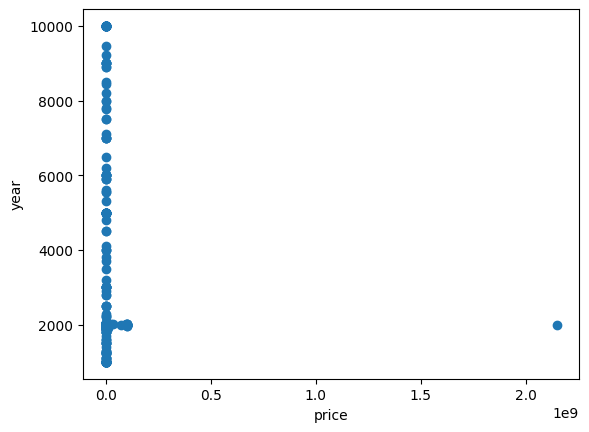

In [19]:
plt.scatter(data_raw['price'], data_raw['yearOfRegistration'])
plt.xlabel('price')
plt.ylabel('year')

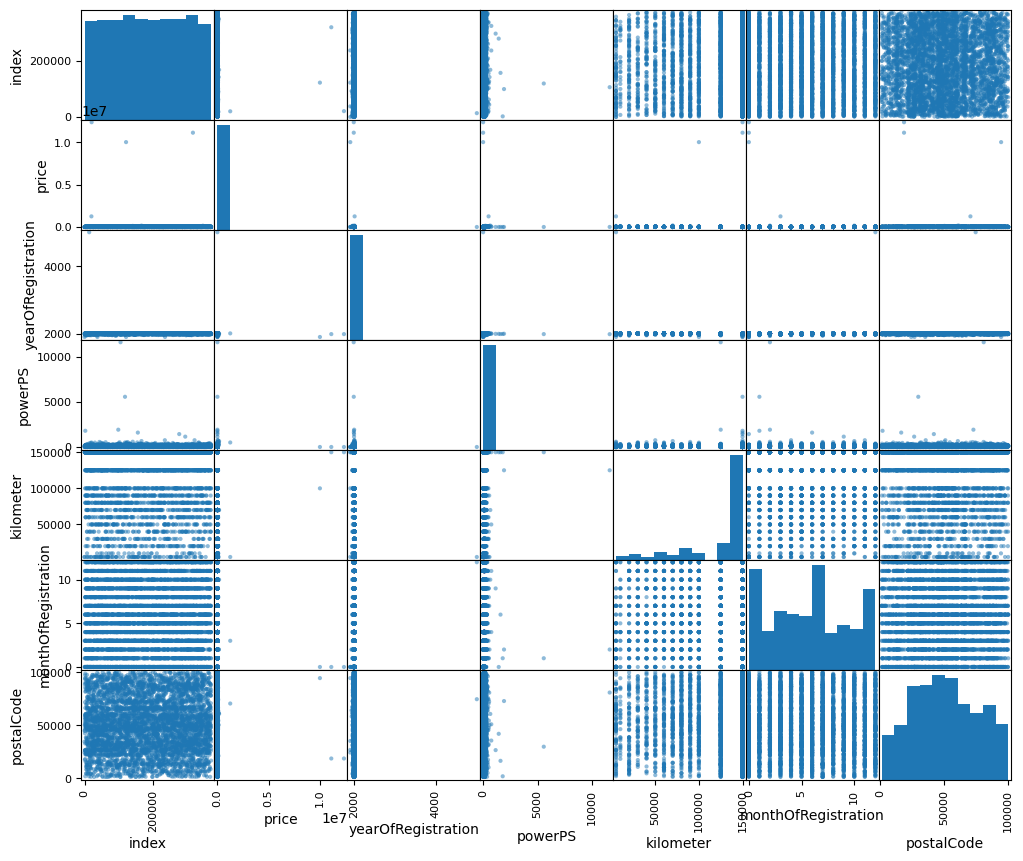

In [20]:
pd.plotting.scatter_matrix(data_raw.sample(5000), figsize = (12, 10))
pass

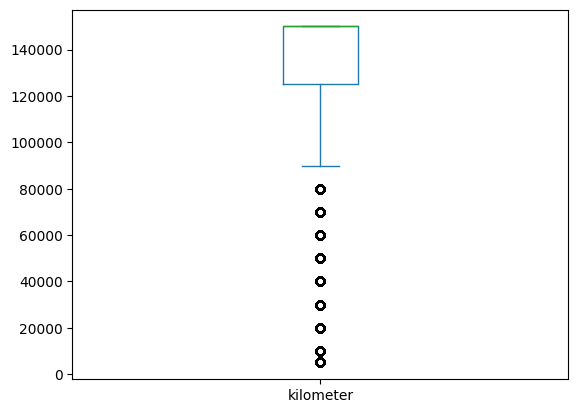

In [21]:
data_raw['kilometer'].plot(kind='box')
pass

Удалим выбросы, связанные с ценой автомобиля (иногда продавцы спецаильно ставят очень завышенную цену машины или наоборот самый низ рынка или вообще около нуля, такие записи точно нужно исключить).
Удалим выбросы, связанные с годом постановки на учет.
Так же нашлись выбросы по мощности двигателя, удалим слишком маленькие и очень большие значения.

In [22]:
data_raw = data_raw[data_raw['price'].between(1000, 500000)]
data_raw = data_raw[data_raw['yearOfRegistration'].between(1970, 2022)]
data_raw = data_raw[data_raw['powerPS'].between(10, 1000)]

data = data_raw

Построим основные квантили

In [23]:
data['price'].quantile([.005, 0.01, 0.05, 0.1, 0.5, 0.9, 0.99, 0.995])

,price
0.005,1000.0
0.010,1000.0
0.050,1200.0
0.100,1450.0
0.500,4500.0
0.900,16399.0
0.990,39000.0
0.995,49990.0


In [24]:
data['powerPS'].quantile([.005, 0.01, 0.05, 0.1, 0.5, 0.9, 0.99, 0.995])

,powerPS
0.005,45.0
0.010,50.0
0.050,60.0
0.100,69.0
0.500,122.0
0.900,211.0
0.990,350.0
0.995,408.0


Выберем квантили уровня $0.005$ и $0.995$ и прочее оценим выбросами.
Скорректируем данные еще раз.

Для цены  получаем интервал $[1000, 49900]$

Для мощности двигателя интервал $[45, 408]$

In [25]:
data_raw = data_raw[data_raw['price'].between(1000, 49900)]
data_raw = data_raw[data_raw['powerPS'].between(45, 408)]

data = data_raw

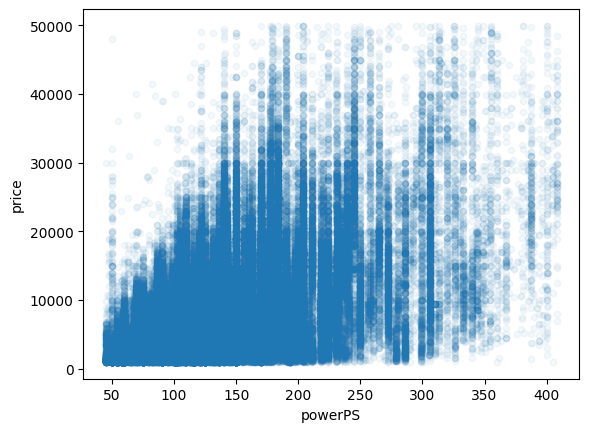

In [26]:
data.plot(kind = 'scatter', x = 'powerPS', y = 'price', alpha=.05)
pass

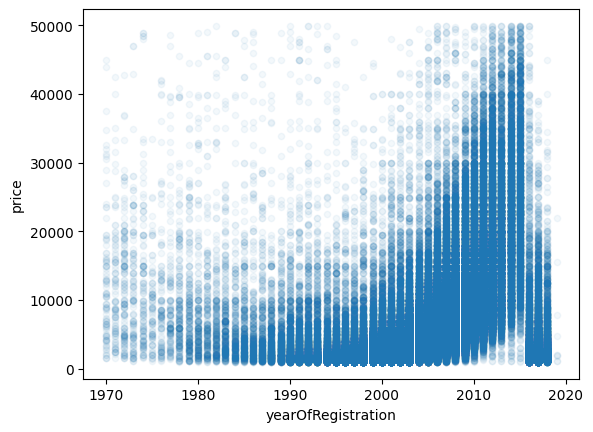

In [27]:
data.plot(kind = 'scatter', x = 'yearOfRegistration', y = 'price', alpha=.05)
pass

In [28]:
data['abtest'].value_counts()

,count
abtest,
test,135512
control,126094


In [29]:
data['vehicleType'].value_counts()

,count
vehicleType,
limousine,73205
kombi,52344
kleinwagen,47279
bus,25599
cabrio,19595
coupe,14443
suv,12980
andere,1884


In [30]:
data['gearbox'].value_counts()

,count
gearbox,
manuell,193598
automatik,64056


In [31]:
data['fuelType'].value_counts()

,count
fuelType,
benzin,150337
diesel,93435
lpg,4269
cng,467
hybrid,232
andere,41
elektro,37


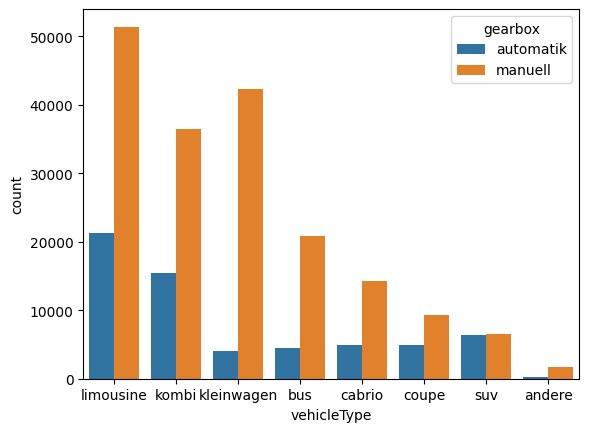

In [32]:
sns.countplot(x='vehicleType', order=data['vehicleType'].value_counts().index, hue='gearbox', data=data)
pass

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


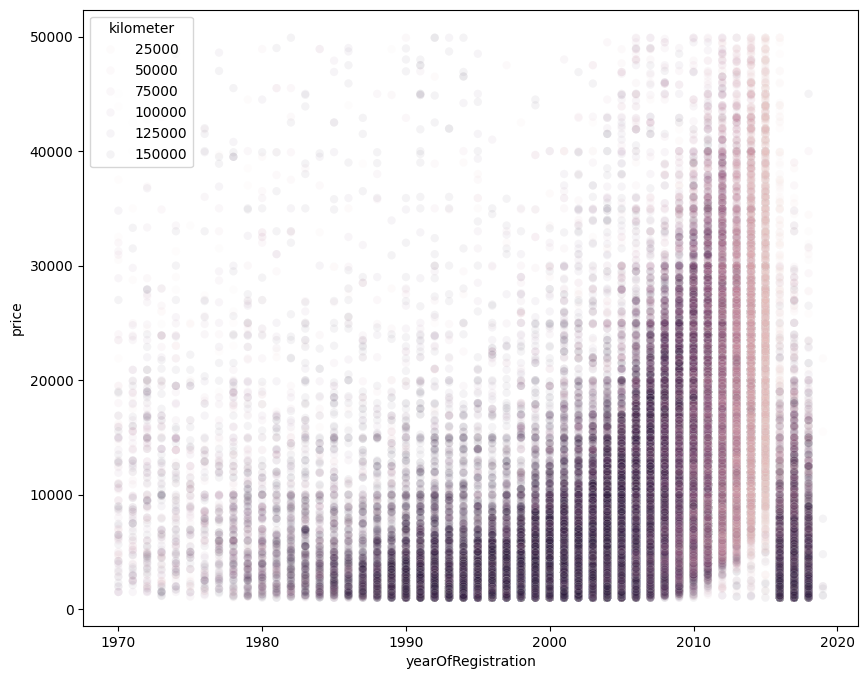

In [33]:
plt.figure(figsize = (10, 8))
sns.scatterplot(x = 'yearOfRegistration', y = 'price',hue = 'kilometer', data=data, alpha=0.05)
pass

Изходя из графиков видно, что при дате регистрации после 2016 года происходит аномальное падение в цене.
Так как в данном периоде не происходило новых законопроектов о продаже авто или иных факторов, которые могли бы привести к такому аномальному изменению, есть смысл предположить, что это выбросы.
Поэтому обновим данные уберем все машины после 2015 года.

Есть предположение, что для авто зарегестрированных после 2016 года, были неверно введен год регестрации, то есть вместо 2006 был по ошибке загружен 2016.
Но менять год регестрации не будем, а просто удалим эти данные.

(Вероятно есть смысл рассмотреть случай, когда эти данные все таки с ошибкой регестрации, и тогда посмотреть на модель регрессии)

In [34]:
data_raw = data_raw[data_raw['yearOfRegistration'].between(1970, 2015)]
data=data_raw

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


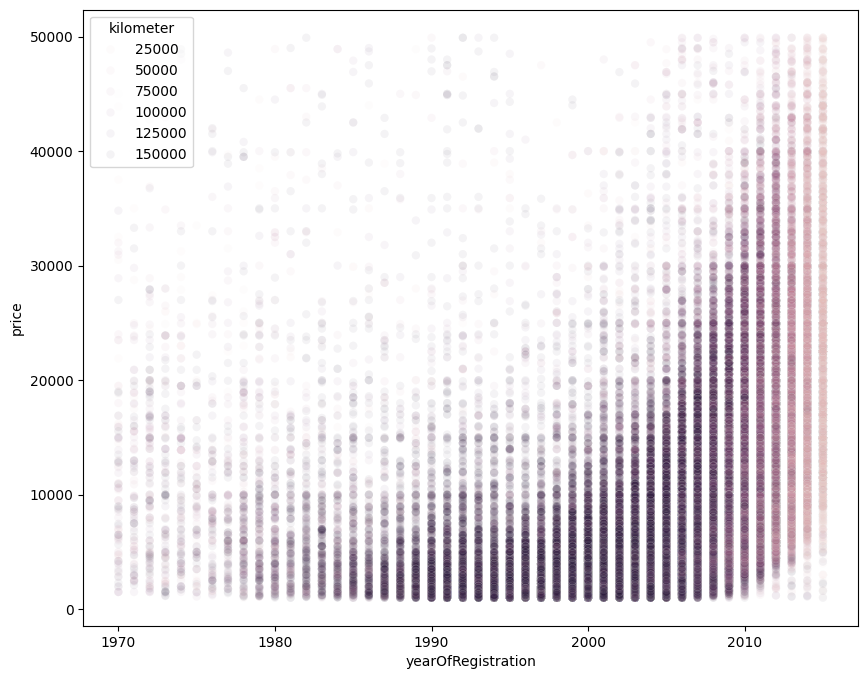

In [35]:
plt.figure(figsize = (10, 8))
sns.scatterplot(x = 'yearOfRegistration', y = 'price',hue = 'kilometer', data=data, alpha=0.05)
pass

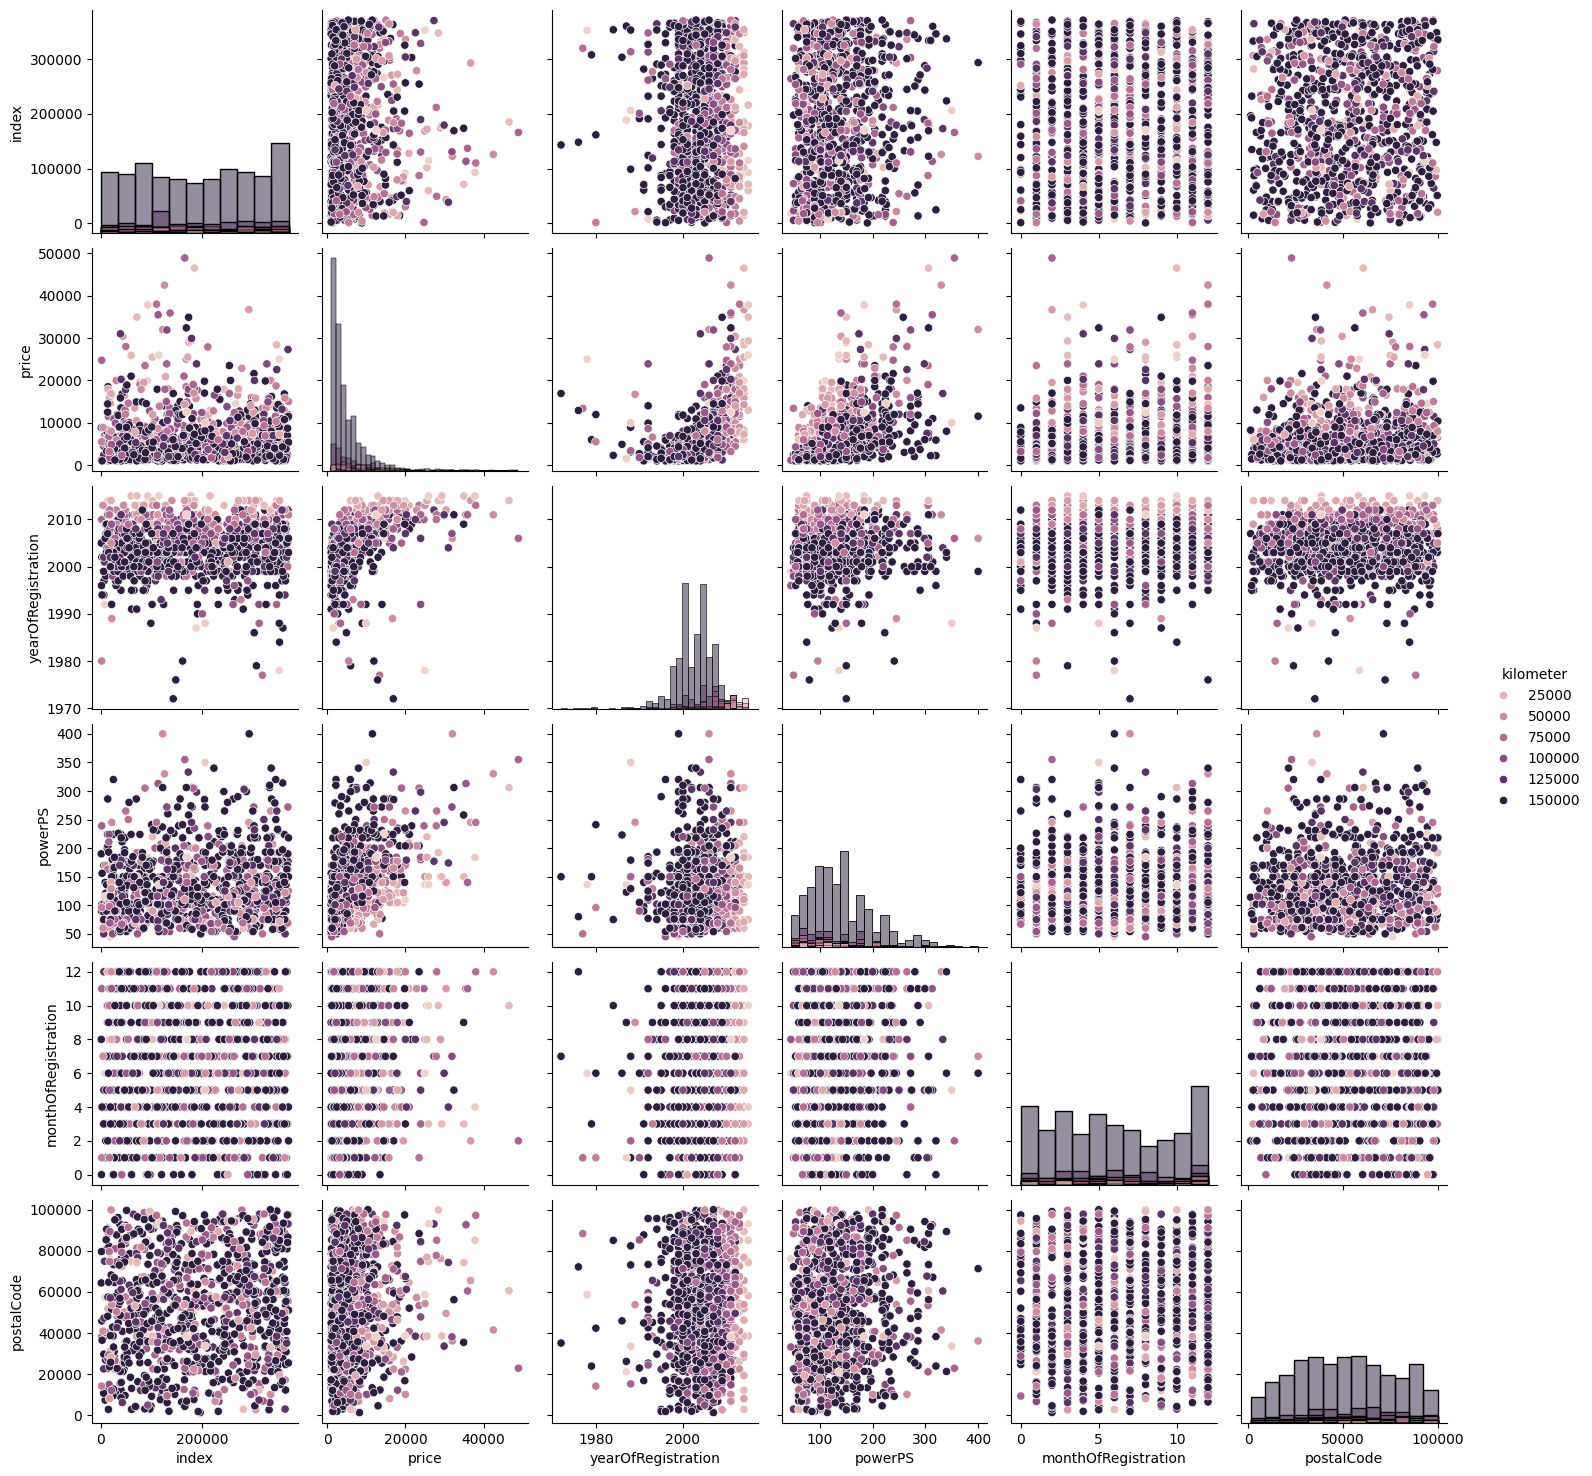

In [36]:
sns.pairplot(data.sample(1000), hue='kilometer', diag_kind='hist')
pass

Построим гистограммы

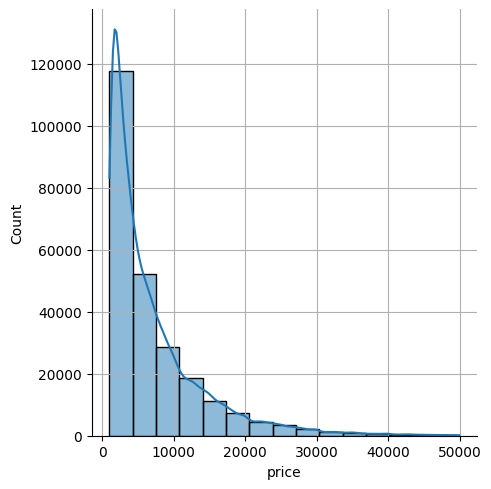

In [37]:
sns.displot(data['price'], bins=15, kde=True)
plt.grid()
pass

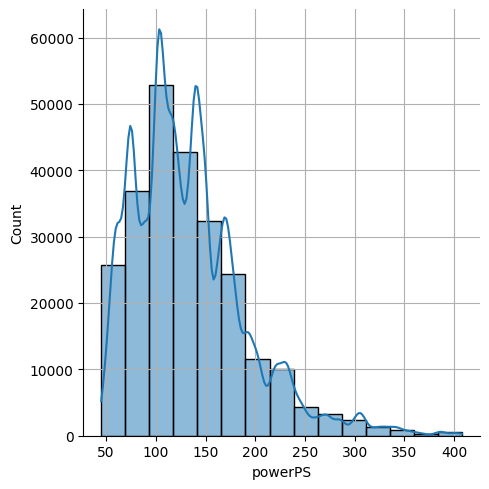

In [38]:
sns.displot(data['powerPS'], bins=15, kde=True)
plt.grid()
pass

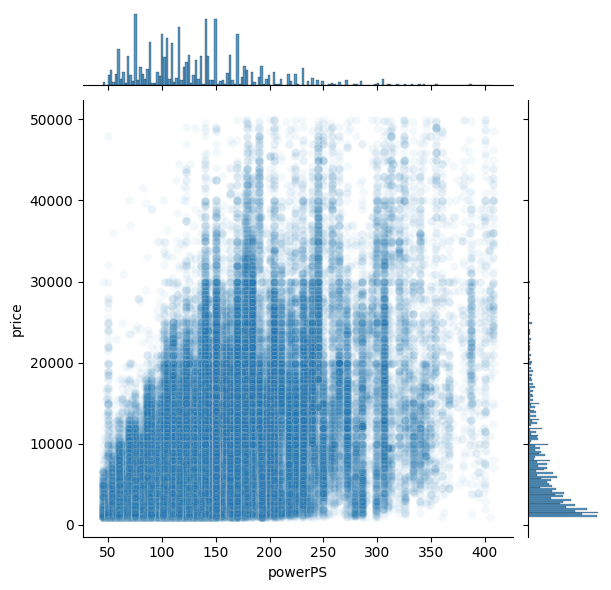

In [39]:
sns.jointplot(x='powerPS', y='price', alpha=0.05, data=data)
pass

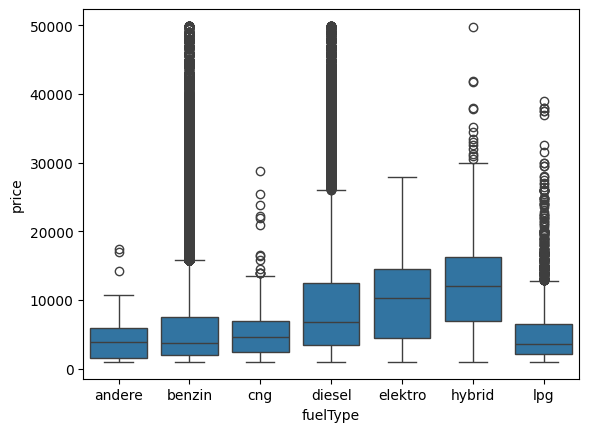

In [40]:
sns.boxplot(x='fuelType', y='price', data=data)
pass

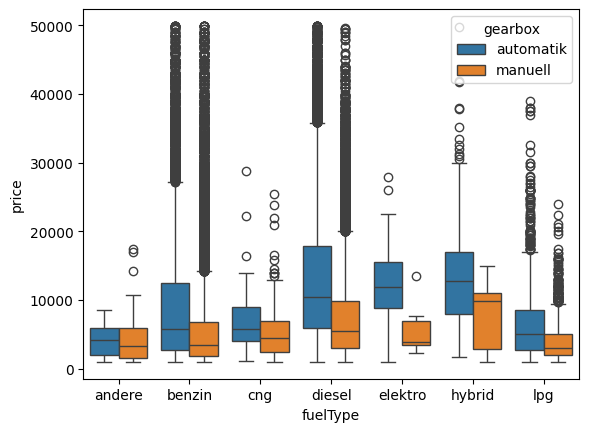

In [41]:
sns.boxplot(x='fuelType', y='price',hue='gearbox', data=data)
pass

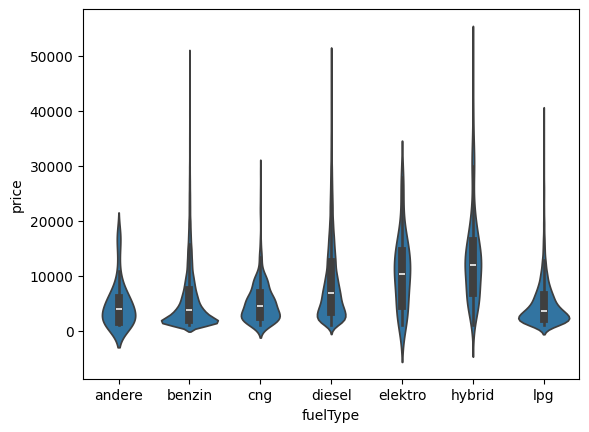

In [42]:
sns.violinplot(x='fuelType', y='price', data=data)
pass

Матрица корреляции


In [43]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
index,1.000000,-0.003829,-0.002397,0.000642,0.003406,-0.000301,0.001428
price,-0.003829,1.000000,0.502029,0.535781,-0.457921,0.028075,0.074869
yearOfRegistration,-0.002397,0.502029,1.000000,0.108880,-0.420984,0.034121,0.034317
powerPS,0.000642,0.535781,0.108880,1.000000,0.059532,0.018889,0.053662
kilometer,0.003406,-0.457921,-0.420984,0.059532,1.000000,-0.011207,-0.029213
monthOfRegistration,-0.000301,0.028075,0.034121,0.018889,-0.011207,1.000000,0.000982
postalCode,0.001428,0.074869,0.034317,0.053662,-0.029213,0.000982,1.000000


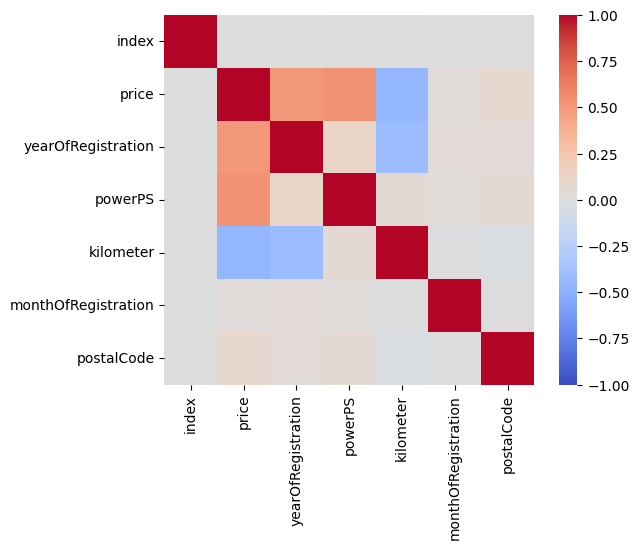

In [44]:
sns.heatmap(corr_matrix, square=True, vmin=-1, vmax=1, cmap='coolwarm')
pass

Построим матрицу корреляции.
Заметим, что цена автомобиля зависит от мощности двигателя, чем больше, тем дороже.
Цена так же больше, если год постановки на учет более новый, то есть в предположении, что машины более новые.
При этом заметим отрицательные показатели корреляции, например, зависимость мощности двигателя от пробега машины, и зависимость года регистарции автомобиля от пробега машины.

Остальные взаимосвязи около равны нулю,

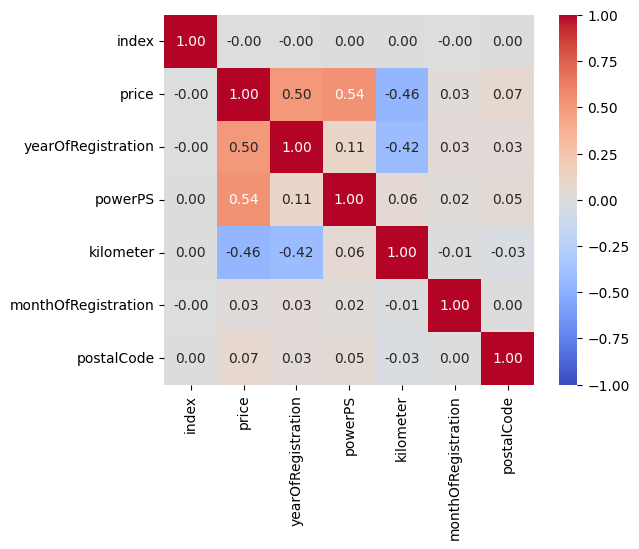

In [45]:
sns.heatmap(corr_matrix, square=True, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm')
pass

## 3.Обучение, тестовая выборка


In [46]:
data

,index,dateCrawled,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,notRepairedDamage,dateCreated,postalCode,lastSeen
1,1,2016-03-24 10:58:45,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,ja,2016-03-24 00:00:00,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,NaN,2016-03-14 00:00:00,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,nein,2016-03-17 00:00:00,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,nein,2016-03-31 00:00:00,60437,2016-04-06 10:17:21
6,6,2016-04-01 20:48:51,2200,test,cabrio,2004,manuell,109,2_reihe,150000,8,benzin,nein,2016-04-01 00:00:00,67112,2016-04-05 18:18:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371520,371520,2016-03-19 19:53:49,3200,control,limousine,2004,manuell,225,leon,150000,5,benzin,ja,2016-03-19 00:00:00,96465,2016-03-19 20:44:43
371524,371524,2016-03-05 19:56:21,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,nein,2016-03-05 00:00:00,26135,2016-03-11 18:17:12
371525,371525,2016-03-19 18:57:12,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,nein,2016-03-19 00:00:00,87439,2016-04-07 07:15:26
371526,371526,2016-03-20 19:41:08,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,NaN,2016-03-20 00:00:00,40764,2016-03-24 12:45:21


In [47]:
X = data.drop(['price', 'index', 'postalCode', 'dateCrawled', 'model', 'dateCreated', 'lastSeen'], axis=1)
y = data['price']

In [48]:
type(X)

pandas.core.frame.DataFrame

In [49]:
type(y)

pandas.core.series.Series

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=21)

N_train, d = X_train.shape
N_test, d = X_test.shape

N_train, N_test, d

(187261, 62421, 9)

In [51]:
X_train

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,monthOfRegistration,fuelType,notRepairedDamage
161528,control,bus,2004,manuell,140,150000,12,diesel,nein
36763,test,kombi,2005,manuell,150,150000,9,benzin,nein
55943,test,limousine,2002,manuell,150,150000,3,diesel,nein
347558,test,limousine,2010,automatik,204,50000,8,diesel,nein
154353,control,limousine,1996,manuell,122,150000,6,benzin,nein
...,...,...,...,...,...,...,...,...,...
121920,test,bus,2012,manuell,120,50000,11,benzin,nein
208334,control,cabrio,2006,manuell,109,150000,3,diesel,nein
301293,test,kleinwagen,2002,NaN,61,70000,6,benzin,nein
105297,test,limousine,2011,manuell,70,70000,2,benzin,nein


In [52]:
X_test

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,monthOfRegistration,fuelType,notRepairedDamage
302178,control,cabrio,1997,manuell,110,150000,5,benzin,NaN
329801,test,limousine,2013,automatik,211,20000,11,benzin,nein
154005,control,kleinwagen,2006,manuell,55,80000,10,benzin,NaN
269096,control,kleinwagen,2013,manuell,90,125000,1,diesel,nein
47001,test,bus,2011,manuell,105,30000,10,benzin,nein
...,...,...,...,...,...,...,...,...,...
218999,test,bus,2012,manuell,102,40000,9,diesel,nein
183627,control,limousine,1998,manuell,193,150000,4,benzin,nein
50766,test,kombi,2007,automatik,170,150000,1,diesel,nein
176566,control,kombi,1998,automatik,125,150000,2,benzin,nein


##  4.Заполнение пропущенных значений


In [53]:
X_train.isna().sum()

,0
abtest,0
vehicleType,2004
yearOfRegistration,0
gearbox,2434
powerPS,0
kilometer,0
monthOfRegistration,0
fuelType,6059
notRepairedDamage,20685


In [54]:
X_test.isna().sum()

,0
abtest,0
vehicleType,624
yearOfRegistration,0
gearbox,821
powerPS,0
kilometer,0
monthOfRegistration,0
fuelType,2057
notRepairedDamage,6855


In [55]:
from sklearn.impute import SimpleImputer
imp_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp_cat.fit(X_train[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

SimpleImputer(strategy='most_frequent')

In [56]:
X_train[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']] = imp_cat.transform(X_train[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

In [57]:
X_train.isna().sum()

,0
abtest,0
vehicleType,0
yearOfRegistration,0
gearbox,0
powerPS,0
kilometer,0
monthOfRegistration,0
fuelType,0
notRepairedDamage,0


## 5.Биномизация номинальных признаков

In [58]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
enc.fit(X_train[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

OneHotEncoder(drop='if_binary', sparse_output=False)

In [59]:
dummies = pd.DataFrame(enc.transform(X_train[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']]),
                        columns=enc.get_feature_names_out(), index=X_train.index)
dummies.head()

,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
161528,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
36763,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55943,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
347558,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
154353,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [60]:
X_train = pd.concat((X_train, dummies), axis=1).drop(['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest'], axis=1)

In [61]:
X_train.head()

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,...,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
161528,2004,140,150000,12,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
36763,2005,150,150000,9,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55943,2002,150,150000,3,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
347558,2010,204,50000,8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
154353,1996,122,150000,6,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


##  6.Масшабирование

In [62]:
X_train

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,...,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
161528,2004,140,150000,12,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
36763,2005,150,150000,9,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55943,2002,150,150000,3,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
347558,2010,204,50000,8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
154353,1996,122,150000,6,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121920,2012,120,50000,11,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
208334,2006,109,150000,3,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
301293,2002,61,70000,6,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
105297,2011,70,70000,2,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [63]:
X_test

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,monthOfRegistration,fuelType,notRepairedDamage
302178,control,cabrio,1997,manuell,110,150000,5,benzin,NaN
329801,test,limousine,2013,automatik,211,20000,11,benzin,nein
154005,control,kleinwagen,2006,manuell,55,80000,10,benzin,NaN
269096,control,kleinwagen,2013,manuell,90,125000,1,diesel,nein
47001,test,bus,2011,manuell,105,30000,10,benzin,nein
...,...,...,...,...,...,...,...,...,...
218999,test,bus,2012,manuell,102,40000,9,diesel,nein
183627,control,limousine,1998,manuell,193,150000,4,benzin,nein
50766,test,kombi,2007,automatik,170,150000,1,diesel,nein
176566,control,kombi,1998,automatik,125,150000,2,benzin,nein


In [64]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train =  pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

In [65]:
X_train.describe()

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,...,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
count,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,...,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05,1.872610e+05
mean,-1.053181e-14,-2.174190e-16,4.211782e-18,-4.492567e-17,-3.432033e-17,-2.314583e-17,-8.696760e-17,-5.771279e-17,-9.523939e-18,9.485995e-18,...,1.380592e-16,-1.517759e-19,-7.103113e-17,-4.553277e-19,4.477389e-17,-1.001721e-17,9.182443e-18,2.071741e-17,-1.202824e-16,7.512908e-18
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-5.727571e+00,-1.546682e+00,-2.936493e+00,-1.758421e+00,-8.815377e-02,-3.374116e-01,-2.914590e-01,-2.472350e-01,-4.838381e-01,-5.150422e-01,...,-1.739488e+00,-1.286747e-02,-1.267175e+00,-4.252330e-02,-7.566538e-01,-1.083960e-02,-3.084557e-02,-1.301249e-01,-3.978431e+00,-1.036880e+00
25%,-5.281784e-01,-7.245420e-01,-5.691964e-01,-9.024553e-01,-8.815377e-02,-3.374116e-01,-2.914590e-01,-2.472350e-01,-4.838381e-01,-5.150422e-01,...,5.748817e-01,-1.286747e-02,-1.267175e+00,-4.252330e-02,-7.566538e-01,-1.083960e-02,-3.084557e-02,-1.301249e-01,2.513554e-01,-1.036880e+00
50%,1.427110e-01,-1.997717e-01,6.767493e-01,-4.648987e-02,-8.815377e-02,-3.374116e-01,-2.914590e-01,-2.472350e-01,-4.838381e-01,-5.150422e-01,...,5.748817e-01,-1.286747e-02,7.891569e-01,-4.252330e-02,-7.566538e-01,-1.083960e-02,-3.084557e-02,-1.301249e-01,2.513554e-01,9.644313e-01
75%,6.458781e-01,5.174143e-01,6.767493e-01,8.094756e-01,-8.815377e-02,-3.374116e-01,-2.914590e-01,-2.472350e-01,-4.838381e-01,-5.150422e-01,...,5.748817e-01,-1.286747e-02,7.891569e-01,-4.252330e-02,1.321608e+00,-1.083960e-02,-3.084557e-02,-1.301249e-01,2.513554e-01,9.644313e-01
max,1.819935e+00,4.803038e+00,6.767493e-01,1.665441e+00,1.134381e+01,2.963739e+00,3.431014e+00,4.044735e+00,2.066807e+00,1.941588e+00,...,5.748817e-01,7.771536e+01,7.891569e-01,2.351652e+01,1.321608e+00,9.225434e+01,3.241956e+01,7.684924e+00,2.513554e-01,9.644313e-01


##  7.Обучение моделей!


**Линейная регрессия**

- Создаем модель и задаем гиперпараметры (конструктор)
- Тренируем модель (метод `fit`)
- Используем модель на новых данных (метод `predict`) и измеряем качество модели

Ищем коэффициенты (веса) $\beta_0, \beta_1, \dots, \beta_d$ _линейной модели_
$$
f(x) = \beta_0 + \sum_{j=1}^d \beta_j x_j,
$$
минимизирующие остаточную сумму квадратов
$$
{\rm RSS} = \sum_{i=1}^N \left(f(x^{(i)}) - y^{(i)}\right)^2
$$

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [67]:
y_train_predict = model.predict(X_train)

In [68]:
model.coef_

array([ 1.70007098e+03,  3.19180626e+03, -2.66148477e+03, -7.85320231e+00,
        1.74363211e+01,  1.05337091e+02,  4.95444712e+02,  2.89978279e+02,
       -2.02022603e+02, -3.94875002e+02, -1.67239420e+02,  3.73035239e+02,
       -3.28666180e+02, -4.04608278e+01, -5.19692409e+02, -2.10371451e+01,
        6.05981368e+02, -1.35328613e+01,  6.44966346e+01, -3.06977643e+02,
        5.26634999e+02,  2.11639157e+00])

In [69]:
model.intercept_

np.float64(7054.891285425174)

In [70]:
importances = pd.Series(model.coef_, index=X_train.columns).sort_values(ascending=False)
importances

,0
powerPS,3191.806264
yearOfRegistration,1700.070982
fuelType_diesel,605.981368
notRepairedDamage_nein,526.634999
vehicleType_cabrio,495.444712
vehicleType_suv,373.035239
vehicleType_coupe,289.978279
vehicleType_bus,105.337091
fuelType_hybrid,64.496635
vehicleType_andere,17.436321


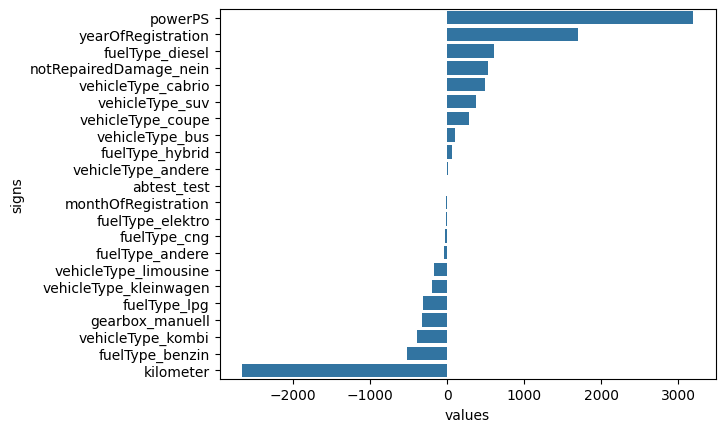

In [71]:
sns.barplot(y=importances.index, x=importances, orient="h")
plt.xlabel('values')
plt.ylabel('signs')
pass

In [72]:
y_train

,price
161528,5200
36763,8799
55943,6450
347558,25900
154353,1850
...,...
121920,11650
208334,3500
301293,2450
105297,6200


In [73]:
y_train_predict

array([7424.3629224 , 4632.93816971, 6725.1532946 , ..., 4575.65641547,
       7804.7362314 , 8907.07410289])

In [74]:
import math

In [75]:
RSS = ((y_train_predict - y_train)**2).sum()
RSS/N_train, math.sqrt(RSS/N_train)

(np.float64(17093325.049910087), 4134.407460557085)

##  8.Тестируем модель

In [76]:
imp_cat.fit(X_test[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

SimpleImputer(strategy='most_frequent')

In [77]:
X_test[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']] = imp_cat.transform(X_test[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

In [78]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
enc.fit(X_test[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']])

OneHotEncoder(drop='if_binary', sparse_output=False)

In [79]:
dummies = pd.DataFrame(enc.transform(X_test[['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest']]),
                        columns=enc.get_feature_names_out(), index=X_test.index)

In [80]:
X_test = pd.concat((X_test, dummies), axis=1).drop(['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage', 'abtest'], axis=1)

In [81]:
X_test =  pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [82]:
X_test

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,...,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
302178,-1.199068,-0.409680,0.676749,-0.331812,-0.088154,-0.337412,3.431014,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
329801,1.484490,1.357047,-2.562709,1.380119,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,-1.739488,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431
154005,0.310433,-1.371759,-1.067575,1.094797,-0.088154,-0.337412,-0.291459,-0.247235,2.066807,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
269096,1.484490,-0.759527,0.053776,-1.473099,-0.088154,-0.337412,-0.291459,-0.247235,2.066807,-0.515042,...,0.574882,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
47001,1.149045,-0.497142,-2.313520,1.094797,-0.088154,2.963739,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218999,1.316768,-0.549619,-2.064331,0.809476,-0.088154,2.963739,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,0.964431
183627,-1.031345,1.042185,0.676749,-0.617133,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
50766,0.478156,0.639861,0.676749,-1.473099,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,1.941588,...,-1.739488,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,0.964431
176566,-1.031345,-0.147295,0.676749,-1.187777,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,1.941588,...,-1.739488,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,-1.036880


In [83]:
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

### Измеряем метрики качества

*Остаточная сумма квадратов* (*residual sum of squares*):
$$
{\rm RSS} = \sum_{i=1}^N \left(y^{(i)} - \widehat{y}^{(i)} \right)^2
$$
где
$$
\widehat{y}^{(i)} = \beta_0 + \sum_{j=1}^d \beta_j x_j^{(i)}
$$

*Полная сумма квадратов*:
$$
{\rm TSS} = \sum_{i=1}^N \left(y^{(i)} - \overline{y} \right)^2,
$$
где
$$
\overline{y} = \frac{1}{N} \sum_{i=1}^N y^{(i)}
$$

$$
\overline{y} = \beta_0 + \sum_{j=1}^d \beta_j \overline{x}_j
$$


*Сумма квадратов, обусловленная регрессией*:
$$
{\rm ESS} = \sum_{i=1}^N \left(\overline{y} - \widehat{y}^{(i)} \right)^2
$$

Можно показать, что
$$
{\rm TSS} = {\rm RSS} + {\rm ESS}
$$

*Коэффициент детерминации*, или *коэффициент регрессии Пирсона*:
$$
R^2 = 1 - \frac{{\rm RSS}}{{\rm TSS}} = \frac{{\rm ESS}}{{\rm TSS}}
$$
— доля объясняемого регрессией разброса относительно среднего (чем ближе к 1, тем модель лучше объясняет данные).

$$
0 \le R^2 \le 1
$$

$R = \sqrt{R^2}$ равно (по модулю) выборочной корреляции между $y^{(i)}$ и $\widehat{y}^{(i)}$

Если $d = 1$, то $R$ равен (по модулю) выборочной корреляции между $y^{(i)}$ и $x^{(i)}$.

*Средний квадрат отклонений* (MSE - Mean Squared Error)
$$
{\rm MSE} = \frac{1}{N} {\rm RSS} = \frac{1}{N} \sum_{i=1}^N \left(y^{(i)} - \widehat{y}^{(i)} \right)^2
$$

*Среднеквадратическая ошибка* (RMSE - Rooted Mean Squared Error)
$$
{\rm RMSE} = \sqrt{{\rm MSE}}
$$

MSE иногда называют *средней квадратической ошибкой*, что, конечно же, правильней отражает суть дела, но добавляет путаницы.

Для вычисления этих метрик можно воспользоваться соответствующими функциями из модуля `metrics` библиотеки `sklearn`, но можно также вычислить "вручную". Значение $R^2$ также вычисляет метод `score` объекта `LinearRegression`

In [84]:
from sklearn.metrics import mean_squared_error, r2_score

MSE_train = mean_squared_error(y_train, y_train_predict)
MSE_test  = mean_squared_error(y_test,  y_test_predict)
R2_train = r2_score(y_train, y_train_predict)
R2_test  = r2_score(y_test,  y_test_predict)
RMSE_train = math.sqrt(MSE_train)
RMSE_test = math.sqrt(MSE_test)

print("MSE на обучающей выборке = ", MSE_train)
print("MSE на тестовой выборке = ", MSE_test)
print("R2 на обучающей выборке = ", R2_train)
print("R2 на тестовой выборке = ", R2_test)
print("RMSE на обучающей выборке = ", RMSE_train)
print("RMSE на тестовой выборке = ", RMSE_test)

MSE на обучающей выборке =  17093325.049910087
MSE на тестовой выборке =  17172833.08232041
R2 на обучающей выборке =  0.6410382466024225
R2 на тестовой выборке =  0.6431055004583426
RMSE на обучающей выборке =  4134.407460557085
RMSE на тестовой выборке =  4144.011713583881


In [85]:
model.score(X_train, y_train)

0.6410382466024225

In [86]:
model.score(X_test, y_test)

0.6431055004583426

In [87]:
RMSE_table = pd.DataFrame(columns=('train', 'test'))
RMSE_table.loc['Linear Regression, all features', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714


In [88]:
R2_table = pd.DataFrame(columns=('train', 'test'))
R2_table.loc['Linear Regression, all features', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106


##  8.1 Подберем количество параметров



Предскажем цену машины только по мощности двигателя

In [89]:
model = LinearRegression()
model.fit(X_train[['powerPS']], y_train)

LinearRegression()

In [90]:
y_train_predict = model.predict(X_train[['powerPS']])
y_test_predict = model.predict(X_test[['powerPS']])

In [91]:
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_predict))
RMSE_test = math.sqrt(mean_squared_error(y_test, y_test_predict))
R2_train = r2_score(y_train, y_train_predict)
R2_test = r2_score(y_test, y_test_predict)

In [92]:
RMSE_table.loc['Linear Regression, PowerPS', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714
"Linear Regression, PowerPS",5820.741757,5874.731635


In [93]:
R2_table.loc['Linear Regression, PowerPS', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106
"Linear Regression, PowerPS",0.288494,0.282744


Если считать только от мощности, то ошибка становится больше.
Теперь добавим другие параметры.


In [94]:
model = LinearRegression()
model.fit(X_train[['yearOfRegistration']], y_train)

LinearRegression()

In [95]:
y_train_predict = model.predict(X_train[['yearOfRegistration']])
y_test_predict = model.predict(X_test[['yearOfRegistration']])

In [96]:
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_predict))
RMSE_test = math.sqrt(mean_squared_error(y_test, y_test_predict))
R2_train = r2_score(y_train, y_train_predict)
R2_test = r2_score(y_test, y_test_predict)

In [97]:
RMSE_table.loc['Linear Regression, yearOfRegistration', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714
"Linear Regression, PowerPS",5820.741757,5874.731635
"Linear Regression, yearOfRegistration",5971.908211,5987.898918


In [98]:
R2_table.loc['Linear Regression, yearOfRegistration', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106
"Linear Regression, PowerPS",0.288494,0.282744
"Linear Regression, yearOfRegistration",0.251059,0.254845


Теперь возьмем оба параметра: мощность двигателя и год постановки на учет.

In [99]:
model = LinearRegression()
model.fit(X_train[['powerPS', 'yearOfRegistration']], y_train)

LinearRegression()

In [100]:
y_train_predict = model.predict(X_train[['powerPS', 'yearOfRegistration']])
y_test_predict = model.predict(X_test[['powerPS', 'yearOfRegistration']])

In [101]:
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_predict))
RMSE_test = math.sqrt(mean_squared_error(y_test, y_test_predict))
R2_train = r2_score(y_train, y_train_predict)
R2_test = r2_score(y_test, y_test_predict)

In [102]:
RMSE_table.loc['Linear Regression, powerPS, yearOfRegistration', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714
"Linear Regression, PowerPS",5820.741757,5874.731635
"Linear Regression, yearOfRegistration",5971.908211,5987.898918
"Linear Regression, powerPS, yearOfRegistration",4944.951806,4975.018396


In [103]:
R2_table.loc['Linear Regression, powerPS, yearOfRegistration', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106
"Linear Regression, PowerPS",0.288494,0.282744
"Linear Regression, yearOfRegistration",0.251059,0.254845
"Linear Regression, powerPS, yearOfRegistration",0.486494,0.485616


Теперь возьмем три параметра: мощность двигателя, год постановки на учет и тип коробки передач.
Два признака числовые(мощность и год), а тип коробки - это категориальный.


In [104]:
X_train

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,vehicleType_andere,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,...,gearbox_manuell,fuelType_andere,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein,abtest_test
161528,-0.025011,0.115090,0.676749,1.665441,-0.088154,2.963739,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
36763,0.142711,0.290014,0.676749,0.809476,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,1.941588,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431
55943,-0.360456,0.290014,0.676749,-0.902455,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,0.964431
347558,0.981323,1.234600,-1.815142,0.524154,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,-1.739488,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,0.964431
154353,-1.366790,-0.199772,0.676749,-0.046490,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121920,1.316768,-0.234756,-1.815142,1.380119,-0.088154,2.963739,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431
208334,0.310433,-0.427172,0.676749,-0.902455,-0.088154,-0.337412,3.431014,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,-1.267175,-0.042523,1.321608,-0.01084,-0.030846,-0.130125,0.251355,-1.036880
301293,-0.360456,-1.266805,-1.316764,-0.046490,-0.088154,-0.337412,-0.291459,-0.247235,2.066807,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431
105297,1.149045,-1.109374,-1.316764,-1.187777,-0.088154,-0.337412,-0.291459,-0.247235,-0.483838,-0.515042,...,0.574882,-0.012867,0.789157,-0.042523,-0.756654,-0.01084,-0.030846,-0.130125,0.251355,0.964431


In [105]:
model = LinearRegression()
model.fit(X_train[['powerPS', 'yearOfRegistration', 'gearbox_manuell']], y_train)
y_train_predict = model.predict(X_train[['powerPS', 'yearOfRegistration', 'gearbox_manuell']])
y_test_predict = model.predict(X_test[['powerPS', 'yearOfRegistration', 'gearbox_manuell']])
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_predict))
RMSE_test = math.sqrt(mean_squared_error(y_test, y_test_predict))
R2_train = r2_score(y_train, y_train_predict)
R2_test = r2_score(y_test, y_test_predict)

In [106]:
RMSE_table.loc['Linear Regression, powerPS, yearOfRegistration, gearbox', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714
"Linear Regression, PowerPS",5820.741757,5874.731635
"Linear Regression, yearOfRegistration",5971.908211,5987.898918
"Linear Regression, powerPS, yearOfRegistration",4944.951806,4975.018396
"Linear Regression, powerPS, yearOfRegistration, gearbox",4924.388206,4953.463022


In [107]:
R2_table.loc['Linear Regression, powerPS, yearOfRegistration, gearbox', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106
"Linear Regression, PowerPS",0.288494,0.282744
"Linear Regression, yearOfRegistration",0.251059,0.254845
"Linear Regression, powerPS, yearOfRegistration",0.486494,0.485616
"Linear Regression, powerPS, yearOfRegistration, gearbox",0.490756,0.490064


### Метод  k  ближайших соседей (k nearest neighbours)

In [108]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors = 5)
model.fit(X_train, y_train)
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_predict))
RMSE_test = math.sqrt(mean_squared_error(y_test, y_test_predict))
R2_train = r2_score(y_train, y_train_predict)
R2_test = r2_score(y_test, y_test_predict)

In [109]:
RMSE_table.loc['k = 5 Nearest Neighbors', :] = (RMSE_train, RMSE_test)
RMSE_table

,train,test
"Linear Regression, all features",4134.407461,4144.011714
"Linear Regression, PowerPS",5820.741757,5874.731635
"Linear Regression, yearOfRegistration",5971.908211,5987.898918
"Linear Regression, powerPS, yearOfRegistration",4944.951806,4975.018396
"Linear Regression, powerPS, yearOfRegistration, gearbox",4924.388206,4953.463022
k = 5 Nearest Neighbors,2411.118575,2961.746827


In [110]:
R2_table.loc['k = 5 Nearest Neighbors', :] = (R2_train, R2_test)
R2_table

,train,test
"Linear Regression, all features",0.641038,0.643106
"Linear Regression, PowerPS",0.288494,0.282744
"Linear Regression, yearOfRegistration",0.251059,0.254845
"Linear Regression, powerPS, yearOfRegistration",0.486494,0.485616
"Linear Regression, powerPS, yearOfRegistration, gearbox",0.490756,0.490064
k = 5 Nearest Neighbors,0.877916,0.817697


Метод $k$ ближайших соседей показывает самую хорошую ошибку $RMSE$ и $R^2$

### Результаты

Провели исследование данных, выявилил выбросы.
Распределили признаки на различные типы.
Проанализировали выбросы и пропущенные значения.
Построили несколько моделей, линейной регрессии и k ближайших соседей.